In [ ]:
# sudo apt install python3-venv
# python3 -m venv myenv
# source myenv/bin/activate
# pip install notebook
# jupyter notebook
# pip install tensorflow keras pandas numpy scikit-learn matplotlib seaborn

In [1]:
# Step 1: Import Libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf

In [6]:
# Step 2: Load Dataset (CSV)
data = pd.read_csv("letter-recognition.csv")

In [7]:
# Step 3: Split Data
X = data.iloc[:, 1:]
y = data.iloc[:, 0]

encoder = LabelEncoder()
y = encoder.fit_transform(y)

In [8]:
# Step 4: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [9]:
# Step 5: Standardization
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [10]:
# Step 6: Build Model
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(16,)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(26, activation='softmax')
])

C:\Users\Dell\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
# Step 7: Compile
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [16]:
# Step 8: Train
history = model.fit(X_train, y_train,
                    epochs=10,
                    batch_size=32,
                    validation_split=0.2)

Epoch 1/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9135 - loss: 0.2914 - val_accuracy: 0.9178 - val_loss: 0.2787
Epoch 2/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9158 - loss: 0.2894 - val_accuracy: 0.9159 - val_loss: 0.2709
Epoch 3/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9206 - loss: 0.2684 - val_accuracy: 0.9216 - val_loss: 0.2606
Epoch 4/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9246 - loss: 0.2501 - val_accuracy: 0.9237 - val_loss: 0.2546
Epoch 5/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9236 - loss: 0.2510 - val_accuracy: 0.9294 - val_loss: 0.2417
Epoch 6/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9278 - loss: 0.2349 - val_accuracy: 0.9278 - val_loss: 0.2420
Epoch 7/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9339 - loss: 0.2239 - val_accuracy: 0.9284 - val_loss: 0.2280
Epoch 8/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9356 - loss: 0.2086 - val_accuracy: 0.

In [17]:
# Step 9: Prediction
y_pred = model.predict(X_test)
y_pred_classes = y_pred.argmax(axis=1)

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


In [18]:
# Step 10: Evaluation
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_classes))
print("\nClassification Report:\n", classification_report(y_test, y_pred_classes))

Confusion Matrix:
 [[161   0   0   0   0   0   0   0   1   2   1   0   0   0   0   1   0   1
    0   0   0   0   0   0   1   0]
 [  0 135   0   2   0   0   0   0   0   1   0   0   0   0   0   0   0   7
    0   0   0   0   0   0   0   0]
 [  0   0 125   0   1   0   2   1   0   0   0   0   0   0   4   0   0   0
    0   0   2   0   0   0   0   0]
 [  0   0   0 116   0   1   1   3   0   1   0   1   1   1   7   0   0   0
    0   4   0   0   0   0   0   0]
 [  0   1   2   0 149   1   1   1   0   0   0   5   0   0   0   0   0   1
    0   2   0   0   0   1   0   1]
 [  0   1   0   0   1 130   0   0   0   0   0   0   0   1   0   5   0   1
    1   5   0   0   0   0   0   0]
 [  0   0   5   0   1   0 118   0   0   0   1   4   1   0   3   0   0   1
    1   0   0   0   0   0   0   0]
 [  0   2   1   7   0   0   2 118   0   1   2   0   1   0   2   0   0  14
    0   0   1   0   0   0   1   0]
 [  0   0   0   0   0   1   0   0 137   8   0   0   0   0   0   1   0   0
    0   0   0   0   0   0   0   1]


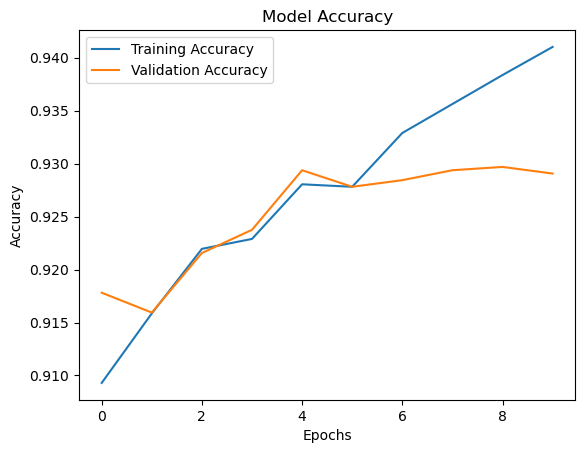

In [19]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend()

plt.show()

In [ ]:
# A. OCR CODE – LINE BY LINE EXPLANATION

# Step 1: Import Libraries
# import pandas as pdfrom sklearn.model_selection import train_test_splitfrom sklearn.preprocessing import LabelEncoder, StandardScalerfrom sklearn.metrics import classification_report, confusion_matriximport tensorflow as tf
# Explanation:


# pandas is used to load dataset from CSV file


# train_test_split is used to divide data into training and testing


# LabelEncoder converts letters into numeric values


# StandardScaler normalizes the data


# classification_report and confusion_matrix are used for evaluation


# tensorflow is used to build deep neural network



# Step 2: Load Dataset
# data = pd.read_csv("letter-recognition.csv")
# Explanation:


# Reads dataset from CSV file into dataframe


# Dataset contains input features and output labels



# Step 3: Separate Input and Output
# X = data.iloc[:, 1:]y = data.iloc[:, 0]
# Explanation:


# X contains all feature columns


# y contains output column (letters A–Z)



# Step 4: Label Encoding
# encoder = LabelEncoder()y = encoder.fit_transform(y)
# Explanation:


# Converts categorical labels (A–Z) into numeric values (0–25)


# Required because neural network works with numbers



# Step 5: Train-Test Split
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
# Explanation:


# Splits dataset into training and testing sets


# 80% data used for training and 20% for testing



# Step 6: Standardization
# scaler = StandardScaler()X_train = scaler.fit_transform(X_train)X_test = scaler.transform(X_test)
# Explanation:


# StandardScaler normalizes data


# fit_transform is applied on training data


# transform is applied on testing data



# Step 7: Build Model
# model = tf.keras.models.Sequential([    tf.keras.layers.Dense(64, activation='relu', input_shape=(16,)),    tf.keras.layers.Dense(32, activation='relu'),    tf.keras.layers.Dense(26, activation='softmax')])
# Explanation:


# Sequential model means layers are arranged in sequence


# First layer has 64 neurons and takes 16 input features


# Second layer has 32 neurons


# Output layer has 26 neurons for 26 classes


# ReLU is used for hidden layers


# Softmax is used for multiclass classification



# Step 8: Compile Model
# model.compile(optimizer='adam',              loss='sparse_categorical_crossentropy',              metrics=['accuracy'])
# Explanation:


# Adam optimizer is used to update weights


# sparse categorical crossentropy is used for multiclass classification


# accuracy is used to measure performance



# Step 9: Train Model
# history = model.fit(X_train, y_train,                    epochs=10,                    batch_size=32,                    validation_split=0.2)
# Explanation:


# Model is trained on training data


# epochs define number of iterations


# batch_size defines number of samples per step


# validation_split is used to check performance during training



# Step 10: Prediction
# y_pred = model.predict(X_test)y_pred_classes = y_pred.argmax(axis=1)
# Explanation:


# model.predict gives probabilities for each class


# argmax selects class with highest probability



# Step 11: Evaluation
# print(confusion_matrix(y_test, y_pred_classes))print(classification_report(y_test, y_pred_classes))
# Explanation:


# Confusion matrix shows correct and incorrect predictions


# Classification report shows precision, recall, and F1-score

